<a href="https://colab.research.google.com/github/TERK93/sensor-pulse/blob/main/anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# sensor-pulse — Anomaly Detection
**Dataset:** NASA CMAPSS Turbofan Engine Degradation  
**Stack:** PySpark · Spark SQL · Matplotlib

This notebook detects abnormal sensor behaviour using rolling statistics.

**Approach:** Rolling Z-score — flag readings that deviate more than 2 standard
deviations from the rolling mean. This is a standard baseline method for
anomaly detection in industrial time-series data.

The same technique applies to real production sensor data (temperature,
pressure, vibration) in manufacturing environments like breweries.

## 1. Setup

In [16]:
!pip install pyspark kagglehub matplotlib -q

In [17]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import kagglehub
import shutil
import os

spark = SparkSession.builder \
    .appName("SensorPulse_AnomalyDetection") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Spark version: 4.0.2


## 2. Load Data
Re-run Bronze → Silver to get clean data into memory.

In [18]:
path = kagglehub.dataset_download("behrad3d/nasa-cmaps")
os.makedirs("data/raw", exist_ok=True)
files = ["train_FD001.txt", "train_FD002.txt", "train_FD003.txt", "train_FD004.txt"]
for f in files:
    shutil.copy(f"{path}/CMaps/{f}", f"data/raw/{f}")
    print(f"File ready: data/raw/{f}")

Using Colab cache for faster access to the 'nasa-cmaps' dataset.
File ready: data/raw/train_FD001.txt
File ready: data/raw/train_FD002.txt
File ready: data/raw/train_FD003.txt
File ready: data/raw/train_FD004.txt


In [19]:
from functools import reduce

# Define the schema for the dataset
schema = StructType([
    StructField("engine_id", IntegerType(), True),
    StructField("cycle", IntegerType(), True),
    StructField("op_setting_1", DoubleType(), True),
    StructField("op_setting_2", DoubleType(), True),
    StructField("op_setting_3", DoubleType(), True),
]  + [StructField(f"sensor_{i:02d}", DoubleType(), True) for i in range(1, 22)])

dfs = []
for dataset_name in ["FD001", "FD002", "FD003", "FD004"]:
    df = spark.read.schema(schema).option("sep", " ").option("header", "false") \
        .csv(f"data/raw/train_{dataset_name}.txt") \
        .withColumn("dataset", F.lit(dataset_name))
    dfs.append(df)

df_raw = reduce(lambda a, b: a.union(b), dfs)

key_sensors = ["sensor_02", "sensor_03", "sensor_04", "sensor_07", "sensor_11"]
null_cond = F.lit(False)
for col in ["engine_id", "cycle"] + key_sensors:
    null_cond = null_cond | F.col(col).isNull()

window_engine = Window.partitionBy("dataset", "engine_id")

df_silver = df_raw \
    .withColumn("status", F.when(null_cond, F.lit("invalid_null")).otherwise(F.lit("valid"))) \
    .withColumn("max_cycle", F.max("cycle").over(window_engine)) \
    .withColumn("rul", F.col("max_cycle") - F.col("cycle"))

df_valid = df_silver.filter(F.col("status") == "valid")
df_valid.createOrReplaceTempView("silver_sensors")
print(f"Valid rows: {df_valid.count():,}")

Valid rows: 160,359


## 3. Rolling Z-Score Anomaly Detection

**Method:** For each engine and sensor, compute a rolling mean and standard
deviation over a 20-cycle window. A reading is flagged as anomalous if it
deviates more than 2 standard deviations from the rolling mean.

```
z_score = (current_value - rolling_mean) / rolling_std
anomaly  = ABS(z_score) > 2.0
```

This is sensor-agnostic — the same logic works for temperature, pressure,
vibration, or any continuous time-series signal.

In [20]:
window_rolling = Window.partitionBy("dataset", "engine_id").orderBy("cycle").rowsBetween(-19, 0)

df_anomaly = df_valid \
    .withColumn("s02_rolling_mean", F.avg("sensor_02").over(window_rolling)) \
    .withColumn("s02_rolling_std",  F.stddev("sensor_02").over(window_rolling)) \
    .withColumn("s02_zscore",
        F.when(F.col("s02_rolling_std") > 0,
            (F.col("sensor_02") - F.col("s02_rolling_mean")) / F.col("s02_rolling_std")
        ).otherwise(F.lit(0.0))
    ) \
    .withColumn("s02_anomaly", F.abs(F.col("s02_zscore")) > 2.0) \
    .withColumn("s11_rolling_mean", F.avg("sensor_11").over(window_rolling)) \
    .withColumn("s11_rolling_std",  F.stddev("sensor_11").over(window_rolling)) \
    .withColumn("s11_zscore",
        F.when(F.col("s11_rolling_std") > 0,
            (F.col("sensor_11") - F.col("s11_rolling_mean")) / F.col("s11_rolling_std")
        ).otherwise(F.lit(0.0))
    ) \
    .withColumn("s11_anomaly", F.abs(F.col("s11_zscore")) > 2.0)

df_anomaly.createOrReplaceTempView("anomaly_scores")
print("Anomaly scores computed")

Anomaly scores computed


## 4. Anomaly Summary

In [21]:
summary = spark.sql("""
    SELECT
        engine_id,
        COUNT(*) AS total_cycles,
        SUM(CAST(s02_anomaly AS INT)) AS s02_anomalies,
        SUM(CAST(s11_anomaly AS INT)) AS s11_anomalies,
        ROUND(SUM(CAST(s02_anomaly AS INT)) / COUNT(*) * 100, 1) AS s02_anomaly_pct
    FROM anomaly_scores
    GROUP BY engine_id
    ORDER BY s02_anomaly_pct DESC
""")

print("Top 10 engines by anomaly rate:")
summary.show(10)

total_anomalies = df_anomaly.filter(F.col("s02_anomaly") == True).count()
total_rows = df_anomaly.count()
print(f"Total anomalies detected: {total_anomalies} / {total_rows} rows ({total_anomalies/total_rows*100:.1f}%)")

Top 10 engines by anomaly rate:
+---------+------------+-------------+-------------+---------------+
|engine_id|total_cycles|s02_anomalies|s11_anomalies|s02_anomaly_pct|
+---------+------------+-------------+-------------+---------------+
|       90|         735|           30|           27|            4.1|
|       73|         848|           33|           33|            3.9|
|       39|         832|           29|           37|            3.5|
|       28|         767|           27|           30|            3.5|
|       45|         691|           24|           29|            3.5|
|       57|         685|           24|           32|            3.5|
|        7|        1078|           38|           44|            3.5|
|       67|         888|           30|           33|            3.4|
|       64|         944|           32|           39|            3.4|
|      253|         149|            5|            5|            3.4|
+---------+------------+-------------+-------------+---------------+
on

## 5. Visualisation — Sensor Readings + Anomalies

Plot sensor_02 for a single engine with anomalies highlighted in red.
The rolling mean is shown as a smooth trend line.

Dataset Characteristics:
- FD001: 1 operating condition, 1 fault mode — clean, stable signal
- FD002: 6 operating conditions, 1 fault mode — high volatility from varying loads  
- FD003: 1 operating condition, 2 fault modes — stable signal, more complex degradation
- FD004: 6 operating conditions, 2 fault modes — most complex dataset, highest variance

This variation is intentional — it tests whether anomaly detection generalizes
across different industrial operating environments.

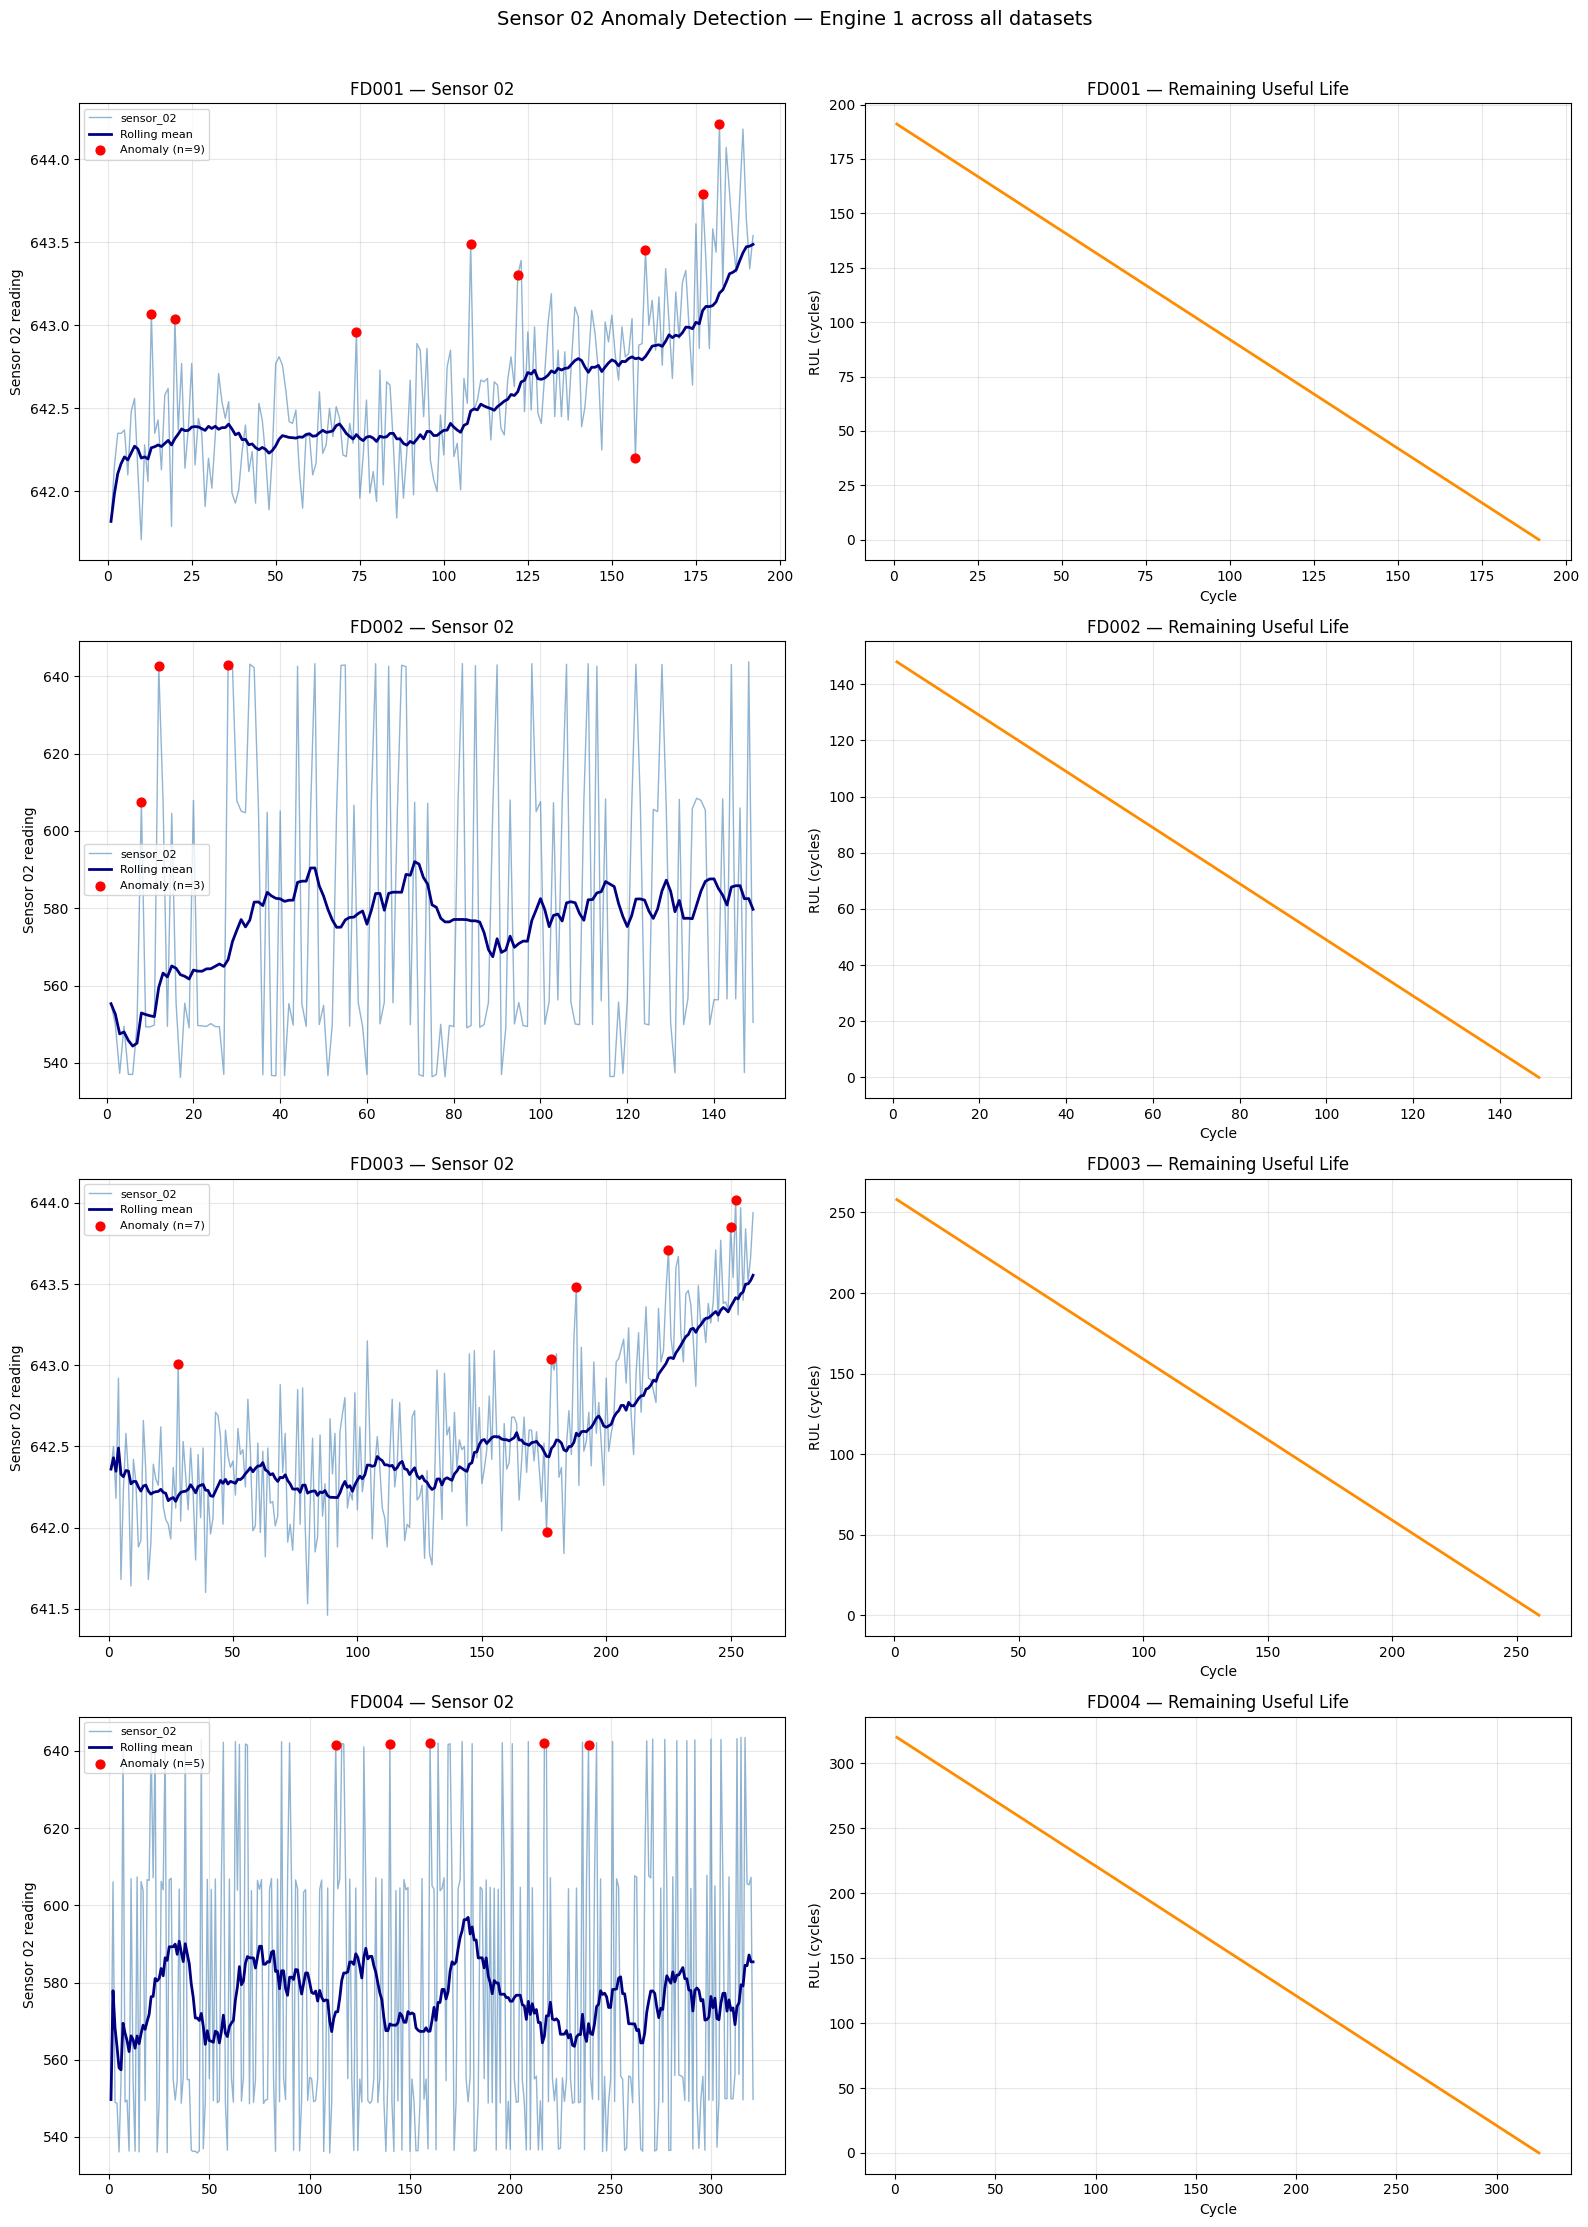

Plot saved as anomaly_plot.png


In [25]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
fig.suptitle("Sensor 02 Anomaly Detection — Engine 1 across all datasets",
             fontsize=14, y=1.01)

for i, dataset_name in enumerate(["FD001", "FD002", "FD003", "FD004"]):
    engine_data = df_anomaly.filter(
        (F.col("engine_id") == 1) & (F.col("dataset") == dataset_name)
    ).select("cycle", "sensor_02", "s02_rolling_mean", "s02_anomaly", "rul") \
     .orderBy("cycle").toPandas()

    anomalies = engine_data[engine_data["s02_anomaly"] == True]

    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    # Sensor + anomalies
    ax1.plot(engine_data["cycle"], engine_data["sensor_02"],
             color="steelblue", alpha=0.6, linewidth=1, label="sensor_02")
    ax1.plot(engine_data["cycle"], engine_data["s02_rolling_mean"],
             color="navy", linewidth=2, label="Rolling mean")
    ax1.scatter(anomalies["cycle"], anomalies["sensor_02"],
                color="red", s=40, zorder=5, label=f"Anomaly (n={len(anomalies)})")
    ax1.set_title(f"{dataset_name} — Sensor 02")
    ax1.set_ylabel("Sensor 02 reading")
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)

    # RUL
    ax2.plot(engine_data["cycle"], engine_data["rul"],
             color="darkorange", linewidth=2)
    ax2.set_title(f"{dataset_name} — Remaining Useful Life")
    ax2.set_ylabel("RUL (cycles)")
    ax2.set_xlabel("Cycle")
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("anomaly_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as anomaly_plot.png")

## 6. Anomaly Timing — Do Anomalies Increase Near End of Life?

In [23]:
timing = spark.sql("""
    SELECT
        CASE
            WHEN rul > 100 THEN 'early (RUL > 100)'
            WHEN rul > 30  THEN 'mid (RUL 30-100)'
            ELSE               'late (RUL < 30)'
        END AS life_stage,
        COUNT(*) AS total_readings,
        SUM(CAST(s02_anomaly AS INT)) AS anomalies,
        ROUND(SUM(CAST(s02_anomaly AS INT)) / COUNT(*) * 100, 2) AS anomaly_rate_pct
    FROM anomaly_scores
    GROUP BY life_stage
    ORDER BY anomaly_rate_pct DESC
""")

print("Anomaly rate by life stage:")
timing.show()
print("If anomaly rate is highest in 'late' — the model is picking up real degradation signals.")

Anomaly rate by life stage:
+-----------------+--------------+---------+----------------+
|       life_stage|total_readings|anomalies|anomaly_rate_pct|
+-----------------+--------------+---------+----------------+
|  late (RUL < 30)|         21979|      519|            2.36|
| mid (RUL 30-100)|         49630|      958|            1.93|
|early (RUL > 100)|         88750|     1569|            1.77|
+-----------------+--------------+---------+----------------+

If anomaly rate is highest in 'late' — the model is picking up real degradation signals.


## 7. Write Anomaly Table

In [24]:
os.makedirs("data/gold", exist_ok=True)

df_anomaly.select(
    "dataset", "engine_id", "cycle", "rul",
    "sensor_02", "s02_rolling_mean", "s02_rolling_std", "s02_zscore", "s02_anomaly",
    "sensor_11", "s11_rolling_mean", "s11_rolling_std", "s11_zscore", "s11_anomaly"
).write.mode("overwrite").parquet("data/gold/anomaly_scores")

print("Anomaly table written to data/gold/anomaly_scores")

Anomaly table written to data/gold/anomaly_scores


## Summary

**Method:** Rolling Z-score over 20-cycle window, threshold = 2.0 std deviations

**Why this matters for industrial IoT:**
In a production environment (brewery, manufacturing plant), this same approach
flags abnormal temperature spikes, pressure drops, or vibration patterns —
before they cause equipment failure. That's the core of predictive maintenance.

**Next steps:**
- Tune the window size and threshold per sensor type
- Train a supervised model on `gold_ml_features` to predict RUL
- Add dbt models to formalize the Gold transformations